<a href="https://colab.research.google.com/github/dea43325108-crypto/Jobsheet-AI/blob/main/Jobsheet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Dea Cantika
- **NIM:** 4.33.25.1.08
- **Kelas:** TI-1B

## Menentukan Pertanyaan Bisnis

#- Pertanyaan 1:
Bagaimana pengaruh musim (season) terhadap jumlah total penyewaan sepeda pada periode tahun 2011-2012?

#- Pertanyaan 2:
Pada jam berapa penyewaan sepeda harian mencapai titik puncaknya (tertinggi) secara rata-rata?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [3]:
# Memuat data dari file CSV
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama day_df
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data

In [4]:
# Memeriksa tipe data dan missing value
print(day_df.info())
print("\nMissing values di day_df:\n", day_df.isnull().sum())

print("\n", "-"*30, "\n")

print(hour_df.info())
print("\nMissing values di hour_df:\n", hour_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values di day_df:
 instant       0
dteday        0
season        0
yr          

### Cleaning Data

In [5]:
# Mengubah tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping nama musim agar lebih mudah dibaca (1: Springer, 2: Summer, 3: Fall, 4: Winter)
season_mapping = {1: 'Springer', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_name'] = day_df['season'].map(season_mapping)

print("Data cleaning selesai.")

Data cleaning selesai.


## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
# Menghitung total penyewaan berdasarkan musim
rentals_by_season = day_df.groupby('season_name')['cnt'].sum().reset_index()
rentals_by_season = rentals_by_season.sort_values(by='cnt', ascending=False)
print(rentals_by_season)

print("\n", "-"*30, "\n")

# Menghitung rata-rata penyewaan per jam
rentals_by_hour = hour_df.groupby('hr')['cnt'].mean().reset_index()
peak_hour = rentals_by_hour.loc[rentals_by_hour['cnt'].idxmax()]
print(f"Puncak penyewaan terjadi pada jam {int(peak_hour['hr'])}:00 dengan rata-rata {peak_hour['cnt']:.2f} penyewaan.")

  season_name      cnt
0        Fall  1061129
2      Summer   918589
3      Winter   841613
1    Springer   471348

 ------------------------------ 

Puncak penyewaan terjadi pada jam 17:00 dengan rata-rata 461.45 penyewaan.


## Visualization & Explanatory Analysis

### Pertanyaan 1:

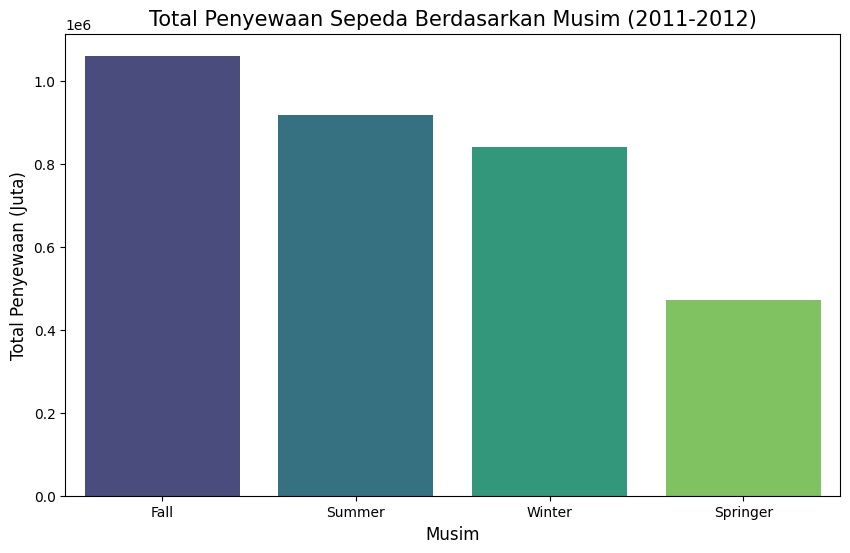

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x='season_name', y='cnt', data=rentals_by_season, hue='season_name', palette='viridis', legend=False)
plt.title('Total Penyewaan Sepeda Berdasarkan Musim (2011-2012)', fontsize=15)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('Total Penyewaan (Juta)', fontsize=12)
plt.show()

### Pertanyaan 2:

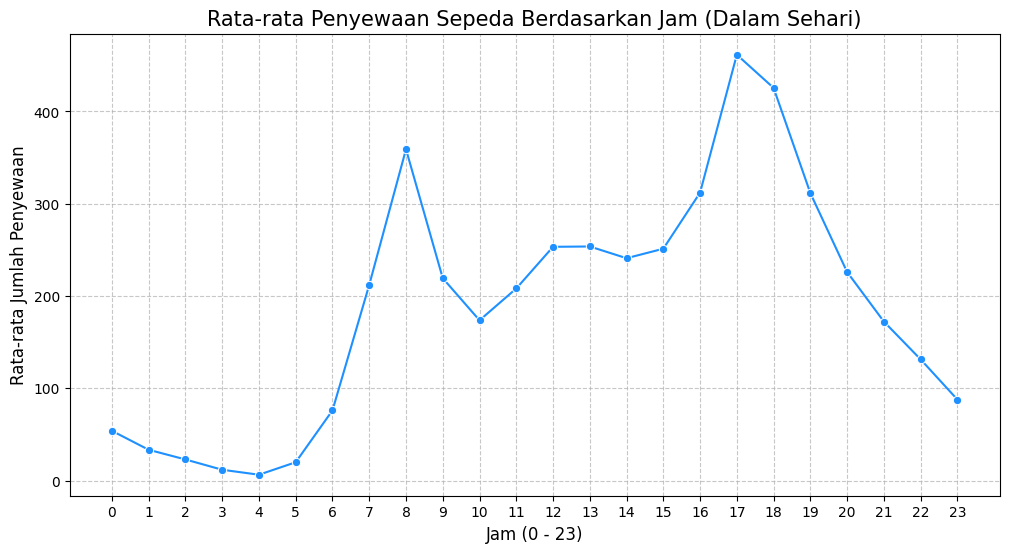

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=rentals_by_hour, marker='o', color='dodgerblue')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam (Dalam Sehari)', fontsize=15)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(np.arange(0, 24, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Conclusion

## Conclusion

- **Conclusion Pertanyaan 1:**
Berdasarkan analisis visualisasi, musim (season) memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Total penyewaan sepeda paling tinggi terjadi pada musim gugur (Fall) dan musim panas (Summer). Sebaliknya, penyewaan sepeda paling rendah terjadi pada musim semi (Springer). Hal ini menunjukkan bahwa pengguna lebih suka bersepeda saat cuaca hangat atau tidak ekstrem.

- **Conclusion Pertanyaan 2:**
Berdasarkan rata-rata harian penyewaan per jam, puncak penyewaan terjadi pada pukul 17:00 (5 Sore) dan 08:00 (8 Pagi). Lonjakan pada kedua jam tersebut sangat berkaitan dengan waktu sibuk komuter, yaitu jam berangkat bekerja/sekolah di pagi hari dan jam pulang di sore hari. Sementara itu, titik terendah penyewaan terjadi pada dini hari (pukul 04:00).